In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

backend = BasicSimulator()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached qiskit-aer-0.15.1.tar.gz (6.6 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build qiskit-aer
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for qiskit-aer (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [113 lines of output]
      C:\Users\Marc\AppData\Local\Temp\pip-build-env-3urklhl8\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: Apache Software License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ********************************************************************************
      
      !!
        self._finalize_license_expression()
      
      
      --------------------------------------------------------------------------------


Note: you may need to restart the kernel to use updated packages.


In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.


## Quantum Random Number Generator

We generate random bits by putting a qubit into the $|+\rangle$ state (using a Hadamard gate) and measuring it. This provides a true 50/50 probability, satisfying the requirement to use quantum randomness instead of Python's `random` library.

In [3]:
def quantum_random_bits(n):
    """Generates n random bits using quantum measurement of the |+> state."""
    bits = []
    for _ in range(n):
        qc = QuantumCircuit(1, 1)
        qc.h(0)
        qc.measure(0, 0)
        t_qc = transpile(qc, backend)
        result = backend.run(t_qc, shots=1).result()
        bits.append(int(list(result.get_counts().keys())[0]))
    return bits

## Alice's Part

Alice's first 10 generated bits:  [0, 1, 1, 1, 0, 1, 1, 1, 1, 1]
Alice's first 10 generated bases: [0, 1, 1, 1, 0, 0, 0, 0, 0, 0]
Alice prepared 40 qubits.
Example Circuit for Qubit 0 (Bit: 0, Basis: 0):


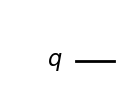

In [4]:
NUM_QUBITS = 40
alice_bits = quantum_random_bits(NUM_QUBITS)
alice_bases = quantum_random_bits(NUM_QUBITS)

print(f"Alice's first 10 generated bits:  {alice_bits[:10]}")
print(f"Alice's first 10 generated bases: {alice_bases[:10]}")

def alice_encode(bit, basis):
    qc = QuantumCircuit(1)
    if bit == 1: qc.x(0)
    if basis == 1: qc.h(0)
    return qc

alice_qubits = [alice_encode(alice_bits[i], alice_bases[i]) for i in range(NUM_QUBITS)]
print(f"Alice prepared {NUM_QUBITS} qubits.")

# Show an example of one of Alice's encoded qubits
print(f"Example Circuit for Qubit 0 (Bit: {alice_bits[0]}, Basis: {alice_bases[0]}):")
display(alice_qubits[0].draw('mpl'))

## Bob's Part

Bob's first 10 generated bases: [0, 1, 1, 1, 0, 1, 0, 1, 0, 1]
Example Bob's Circuit for Qubit 0 (Basis: 0):


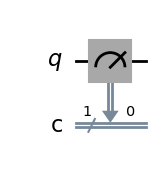

In [5]:
bob_bases = quantum_random_bits(NUM_QUBITS)
print(f"Bob's first 10 generated bases: {bob_bases[:10]}")

bob_circuits = []
def bob_measure(qubit_qc, basis):
    qc = qubit_qc.copy()
    if basis == 1: qc.h(0)
    qc.add_register(__import__('qiskit').ClassicalRegister(1, 'c'))
    qc.measure(0, 0)
    bob_circuits.append(qc)
    t_qc = transpile(qc, backend)
    return int(list(backend.run(t_qc, shots=1).result().get_counts().keys())[0])

bob_bits = [bob_measure(alice_qubits[i], bob_bases[i]) for i in range(NUM_QUBITS)]

print(f"Example Bob's Circuit for Qubit 0 (Basis: {bob_bases[0]}):")
display(bob_circuits[0].draw('mpl'))

## Sifting
Sifting and QBER are classical post-processing steps using Alice and Bob's measured bits.

In [6]:
matching_indices = [i for i in range(NUM_QUBITS) if alice_bases[i] == bob_bases[i]]
alice_key = [alice_bits[i] for i in matching_indices]
bob_key = [bob_bits[i] for i in matching_indices]

error_count = sum(1 for i in range(len(alice_key)) if alice_key[i] != bob_key[i])
qber = error_count / len(alice_key) if len(alice_key) > 0 else 0

print(f"Sifted Key Length: {len(alice_key)}")
print(f"Quantum Bit Error Rate (QBER): {qber:.2%}")
print(f"Keys match: {alice_key == bob_key}")

Sifted Key Length: 20
Quantum Bit Error Rate (QBER): 0.00%
Keys match: True
